# Tâche 3 : Visualisation des effets de site dans les données fMRI

## Contexte

Les tâches 1 et 2 ont montré que les performances du modèle varient selon les sites d'acquisition, et que cette variabilité n'est pas uniquement expliquée par l'âge des participants. La tâche 3 remonte en amont de la chaîne d'analyse pour examiner si ces effets de site sont **visibles directement dans les données fMRI brutes**, avant même toute extraction de features.

## Objectif

Produire deux types de visualisations par site :

1. **Volume moyen par site** : moyenne voxel par voxel de toutes les images fMRI d'un site. Les différences d'intensité, de champ de vue ou de contraste entre sites seront directement visibles.
2. **Carte d'écart-type temporel (tSD) par site** : pour chaque sujet, calculer l'écart-type voxel par voxel sur la série temporelle (axe temps), puis moyenner par site. Les zones avec une forte variabilité temporelle révèlent des artefacts dominants.

## Lien avec les tâches précédentes

- **Tâche 1** : les performances LOSO varient entre 0.44 (OHSU) et 0.75 (LEUVEN) selon le site
- **Tâche 2** : cette variabilité n'est pas uniquement due à l'âge
- **Tâche 3** : on cherche à visualiser si les données fMRI brutes présentent des différences inter-sites qui pourraient expliquer ces résultats

## Instructions de reproduction

Ce notebook suppose que les données ABIDE ont déjà été préparées. Voici les étapes :

```bash
# 1. Cloner le dépôt
git clone https://github.com/psy3019-6973-2026/Francois_Presentation_Projet_ABIDE-fMRI.git
cd Francois_Presentation_Projet_ABIDE-fMRI

# 2. Créer et activer l'environnement
conda env create -f environment.yml
conda activate env_abide

# 3. Préparer les données (~8h)
make prepare

# 4. Lancer ce notebook
cd notebook
jupyter notebook
```

Ce notebook utilise des **chemins relatifs** (`data/` et `output/`) afin d'être reproductible sur n'importe quelle machine.

## 1. Imports

In [27]:
import warnings
from pathlib import Path

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from nilearn import datasets, plotting, image

In [28]:
# Style uniforme pour toutes les figures
# Configuration globale des figures 
# useoffset=False : évite la notation scientifique décalée sur les axes
# limits=(-8000000, 8000000) : affiche les grands nombres normalement
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (-8000000, 8000000)
plt.rcParams['figure.dpi'] = 150 # résolution des figures

## 2. Chargement du phénotype et mapping des sites

In [29]:
project_root = Path(os.getcwd())
if project_root.name == "notebook":
    project_root = project_root.parent

# Dossier des images fMRI brutes prétraitées
fmri_dir     = project_root / "data" / "ABIDE_pcp" / "cpac" / "nofilt_noglobal"

# Dossier des données ABIDE
data_dir     = project_root / "data"

assert fmri_dir.exists(), f"Dossier fMRI introuvable : {fmri_dir}"

# Charger le phénotype
abide = datasets.fetch_abide_pcp(
    data_dir=str(data_dir),
    pipeline="cpac",
    quality_checked=True
)
pheno = pd.DataFrame(abide.phenotypic)
pheno["DX"] = pheno["DX_GROUP"].map({1: "ASD", 2: "TD"})

print(f"Participants dans le phénotype : {len(pheno)}")
print(f"Sites : {sorted(pheno['SITE_ID'].unique())}")

[fetch_abide_pcp] Dataset found in /mnt/d/udem/PSY3019/Francois_Presentation_Projet_ABIDE-fMRI/data/ABIDE_pcp
Participants dans le phénotype : 871
Sites : ['CALTECH', 'CMU', 'KKI', 'LEUVEN_1', 'LEUVEN_2', 'MAX_MUN', 'NYU', 'OHSU', 'OLIN', 'PITT', 'SBL', 'SDSU', 'STANFORD', 'TRINITY', 'UCLA_1', 'UCLA_2', 'UM_1', 'UM_2', 'USM', 'YALE']


In [30]:
# Lister tous les fichiers fMRI disponibles
fmri_files = sorted(fmri_dir.glob("*_func_preproc.nii.gz"))
print(f"Fichiers fMRI trouvés : {len(fmri_files)}")

# Construire un DataFrame fichier → site
# Le nom de fichier est de la forme : SiteName_SubjectID_func_preproc.nii.gz
# Ex : Pitt_0050003_func_preproc.nii.gz → site = Pitt
#      CMU_a_0050642_func_preproc.nii.gz → site = CMU_a
file_records = []
for f in fmri_files:
    # Nom sans extension : ex. Leuven_1_0050682_func_preproc
    stem = f.name.replace("_func_preproc.nii.gz", "")
    parts = stem.split("_")
    
    # Le subject ID est toujours un nombre à 7 chiffres (005XXXX)
    sub_id = None
    sub_idx = None
    for i, p in enumerate(parts):
        if len(p) == 7 and p.isdigit():
            sub_id = int(p)
            sub_idx = i
            break
    
    if sub_id is not None:
        site_name = "_".join(parts[:sub_idx])
        file_records.append({
            "filepath":  f,
            "site_file": site_name,
            "sub_id":    sub_id
        })
    else:
        warnings.warn(f"Impossible de parser : {f.name}", UserWarning)

df_files = pd.DataFrame(file_records)
print(f"Fichiers parsés : {len(df_files)}")
print(f"Sites trouvés : {sorted(df_files['site_file'].unique())}")

Fichiers fMRI trouvés : 871
Fichiers parsés : 871
Sites trouvés : ['CMU_a', 'CMU_b', 'Caltech', 'KKI', 'Leuven_1', 'Leuven_2', 'MaxMun_a', 'MaxMun_b', 'MaxMun_c', 'MaxMun_d', 'NYU', 'OHSU', 'Olin', 'Pitt', 'SBL', 'SDSU', 'Stanford', 'Trinity', 'UCLA_1', 'UCLA_2', 'UM_1', 'UM_2', 'USM', 'Yale']


In [31]:
# Mapping entre noms de sites dans les fichiers et noms dans le phénotype
# Les noms de fichiers utilisent des conventions différentes du phénotype
# Ex : "Leuven_1" dans les fichiers = "LEUVEN_1" dans le phénotype
site_mapping = {
    "Caltech":  "CALTECH",
    "CMU_a":    "CMU",# CMU a deux sous-groupes → même site
    "CMU_b":    "CMU", 
    "KKI":      "KKI",
    "Leuven_1": "LEUVEN_1",
    "Leuven_2": "LEUVEN_2",
    "MaxMun_a": "MAX_MUN", # MAX_MUN a 4 sous-groupes → même site
    "MaxMun_b": "MAX_MUN",
    "MaxMun_c": "MAX_MUN",
    "MaxMun_d": "MAX_MUN",
    "NYU":      "NYU",
    "OHSU":     "OHSU",
    "Olin":     "OLIN",
    "Pitt":     "PITT",
    "SBL":      "SBL",
    "SDSU":     "SDSU",
    "Stanford": "STANFORD",
    "Trinity":  "TRINITY",
    "UCLA_1":   "UCLA_1",
    "UCLA_2":   "UCLA_2",
    "UM_1":     "UM_1",
    "UM_2":     "UM_2",
    "USM":      "USM",
    "Yale":     "YALE",
}

df_files["site"] = df_files["site_file"].map(site_mapping)

# Vérifier les sites non mappés
unmapped = df_files[df_files["site"].isna()]["site_file"].unique()
if len(unmapped) > 0:
    print(f" Sites non mappés : {unmapped}")
else:
    print(" Tous les sites sont mappés")

print(f"\nFichiers par site :")
print(df_files.groupby("site")["filepath"].count().sort_values(ascending=False))

 Tous les sites sont mappés

Fichiers par site :
site
NYU         172
UM_1         86
USM          67
UCLA_1       64
PITT         50
MAX_MUN      46
TRINITY      44
YALE         41
UM_2         34
KKI          33
LEUVEN_1     28
LEUVEN_2     28
OLIN         28
SDSU         27
SBL          26
OHSU         25
STANFORD     25
UCLA_2       21
CALTECH      15
CMU          11
Name: filepath, dtype: int64


## 3. Calcul du volume moyen et de la carte tSD par site

Pour chaque site :
- **Volume moyen** : moyenne voxel par voxel de l'image fMRI moyenne de chaque sujet (`mean_img`)
- **Carte tSD** : écart-type voxel par voxel sur la série temporelle de chaque sujet, puis moyenne par site

On traite **un sujet à la fois** pour éviter de saturer la mémoire (chaque fichier ~100 Mo).

## Vulgarisation :
- **Volume moyen** → "À quoi ressemble un cerveau typique de ce site ?" Si les scanners sont différents, les images ont avoir des intensités ou des formes différentes.

- **Carte tSD** → "Quels voxels bougent beaucoup dans le temps ?" Une forte variabilité diffuse sur tout le cerveau suggère des artefacts d'acquisition.

In [32]:
def compute_site_maps(filepaths):
    """
    Calcule le volume moyen et la carte tSD par site.
    Utilise image.mean_img de nilearn pour le volume moyen.
    """
    mean_imgs = [] # stocke le volume moyen de chaque sujet
    sum_tsd  = None # somme des cartes tSD pour faire la moyenne ensuite
    affine   = None # matrice de transformation spatiale
    n_valid  = 0 # nombre de sujets traités avec succès

    for fp in filepaths:
        try:
            img  = nib.load(str(fp))
            # Volume moyen avec nilearn 
            mean_img_subj = image.mean_img(img)
            mean_imgs.append(mean_img_subj)

            # Carte tSD manuellement
            data = img.get_fdata(dtype=np.float32)
            if data.ndim != 4:
                warnings.warn(f"{fp.name} : pas une image 4D, ignoré.", UserWarning)
                continue

            subj_tsd = data.std(axis=3)

            if sum_tsd is None:
                sum_tsd = subj_tsd.copy()
                affine  = img.affine
            else:
                if subj_tsd.shape != sum_tsd.shape:
                    ref_img  = nib.Nifti1Image(sum_tsd, affine)
                    new_tsd  = nib.Nifti1Image(subj_tsd, img.affine)
                    subj_tsd = image.resample_to_img(new_tsd, ref_img).get_fdata(dtype=np.float32)
                sum_tsd += subj_tsd

            n_valid += 1
            del data, subj_tsd

        except Exception as e:
            warnings.warn(f"{fp.name} : erreur ({e}), ignoré.", UserWarning)
            continue

    if n_valid == 0:
        return None, None

    # Utilise image.mean_img de nilearn pour la moyenne des volumes
    mean_map = image.mean_img(mean_imgs)
    tsd_map  = nib.Nifti1Image(sum_tsd / n_valid, affine)
    return mean_map, tsd_map

In [33]:
# Calcul pour tous les sites
# ATTENTION Cette cellule peut prendre 30 minutes 

sites = sorted(df_files["site"].dropna().unique())
site_mean_maps = {}
site_tsd_maps  = {}

for site in sites:
    filepaths = df_files[df_files["site"] == site]["filepath"].tolist()
    print(f"Traitement site {site} ({len(filepaths)} sujets)...", end=" ", flush=True)

    mean_map, tsd_map = compute_site_maps(filepaths)

    if mean_map is not None:
        site_mean_maps[site] = mean_map
        site_tsd_maps[site]  = tsd_map
        print("ok")
    else:
        print("aucun fichier valide")

print(f"\nSites traités avec succès : {len(site_mean_maps)} / {len(sites)}")

Traitement site CALTECH (15 sujets)... ok
Traitement site CMU (11 sujets)... ok
Traitement site KKI (33 sujets)... ok
Traitement site LEUVEN_1 (28 sujets)... ok
Traitement site LEUVEN_2 (28 sujets)... ok
Traitement site MAX_MUN (46 sujets)... ok
Traitement site NYU (172 sujets)... ok
Traitement site OHSU (25 sujets)... ok
Traitement site OLIN (28 sujets)... ok
Traitement site PITT (50 sujets)... ok
Traitement site SBL (26 sujets)... ok
Traitement site SDSU (27 sujets)... ok
Traitement site STANFORD (25 sujets)... ok
Traitement site TRINITY (44 sujets)... ok
Traitement site UCLA_1 (64 sujets)... ok
Traitement site UCLA_2 (21 sujets)... ok
Traitement site UM_1 (86 sujets)... ok
Traitement site UM_2 (34 sujets)... ok
Traitement site USM (67 sujets)... ok
Traitement site YALE (41 sujets)... ok

Sites traités avec succès : 20 / 20


In [34]:
# Cellule de debug à exécuter si les cartes ne se calculent pas correctement
print(f"Sites dans site_mean_maps : {len(site_mean_maps)}")
print(list(site_mean_maps.keys()))

print(fmri_dir)
print(fmri_dir.exists())
print(len(list(fmri_dir.glob("*_func_preproc.nii.gz"))))

print(len(df_files))
print(df_files.head())
print(df_files["site"].value_counts())

print(list(fmri_dir.glob("*Leuven*"))[:3])

Sites dans site_mean_maps : 20
['CALTECH', 'CMU', 'KKI', 'LEUVEN_1', 'LEUVEN_2', 'MAX_MUN', 'NYU', 'OHSU', 'OLIN', 'PITT', 'SBL', 'SDSU', 'STANFORD', 'TRINITY', 'UCLA_1', 'UCLA_2', 'UM_1', 'UM_2', 'USM', 'YALE']
/mnt/d/udem/PSY3019/Francois_Presentation_Projet_ABIDE-fMRI/data/ABIDE_pcp/cpac/nofilt_noglobal
True
871
871
                                            filepath site_file  sub_id site
0  /mnt/d/udem/PSY3019/Francois_Presentation_Proj...     CMU_a   50642  CMU
1  /mnt/d/udem/PSY3019/Francois_Presentation_Proj...     CMU_a   50647  CMU
2  /mnt/d/udem/PSY3019/Francois_Presentation_Proj...     CMU_a   50649  CMU
3  /mnt/d/udem/PSY3019/Francois_Presentation_Proj...     CMU_a   50654  CMU
4  /mnt/d/udem/PSY3019/Francois_Presentation_Proj...     CMU_a   50656  CMU
site
NYU         172
UM_1         86
USM          67
UCLA_1       64
PITT         50
MAX_MUN      46
TRINITY      44
YALE         41
UM_2         34
KKI          33
LEUVEN_1     28
LEUVEN_2     28
OLIN         28
SDSU      

## 4. Visualisation des volumes moyens par site

On affiche une coupe axiale centrale pour chaque site. Les différences d'intensité ou de champ de vue entre sites sont directement visibles.

/tmp/ipykernel_492/2159500649.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


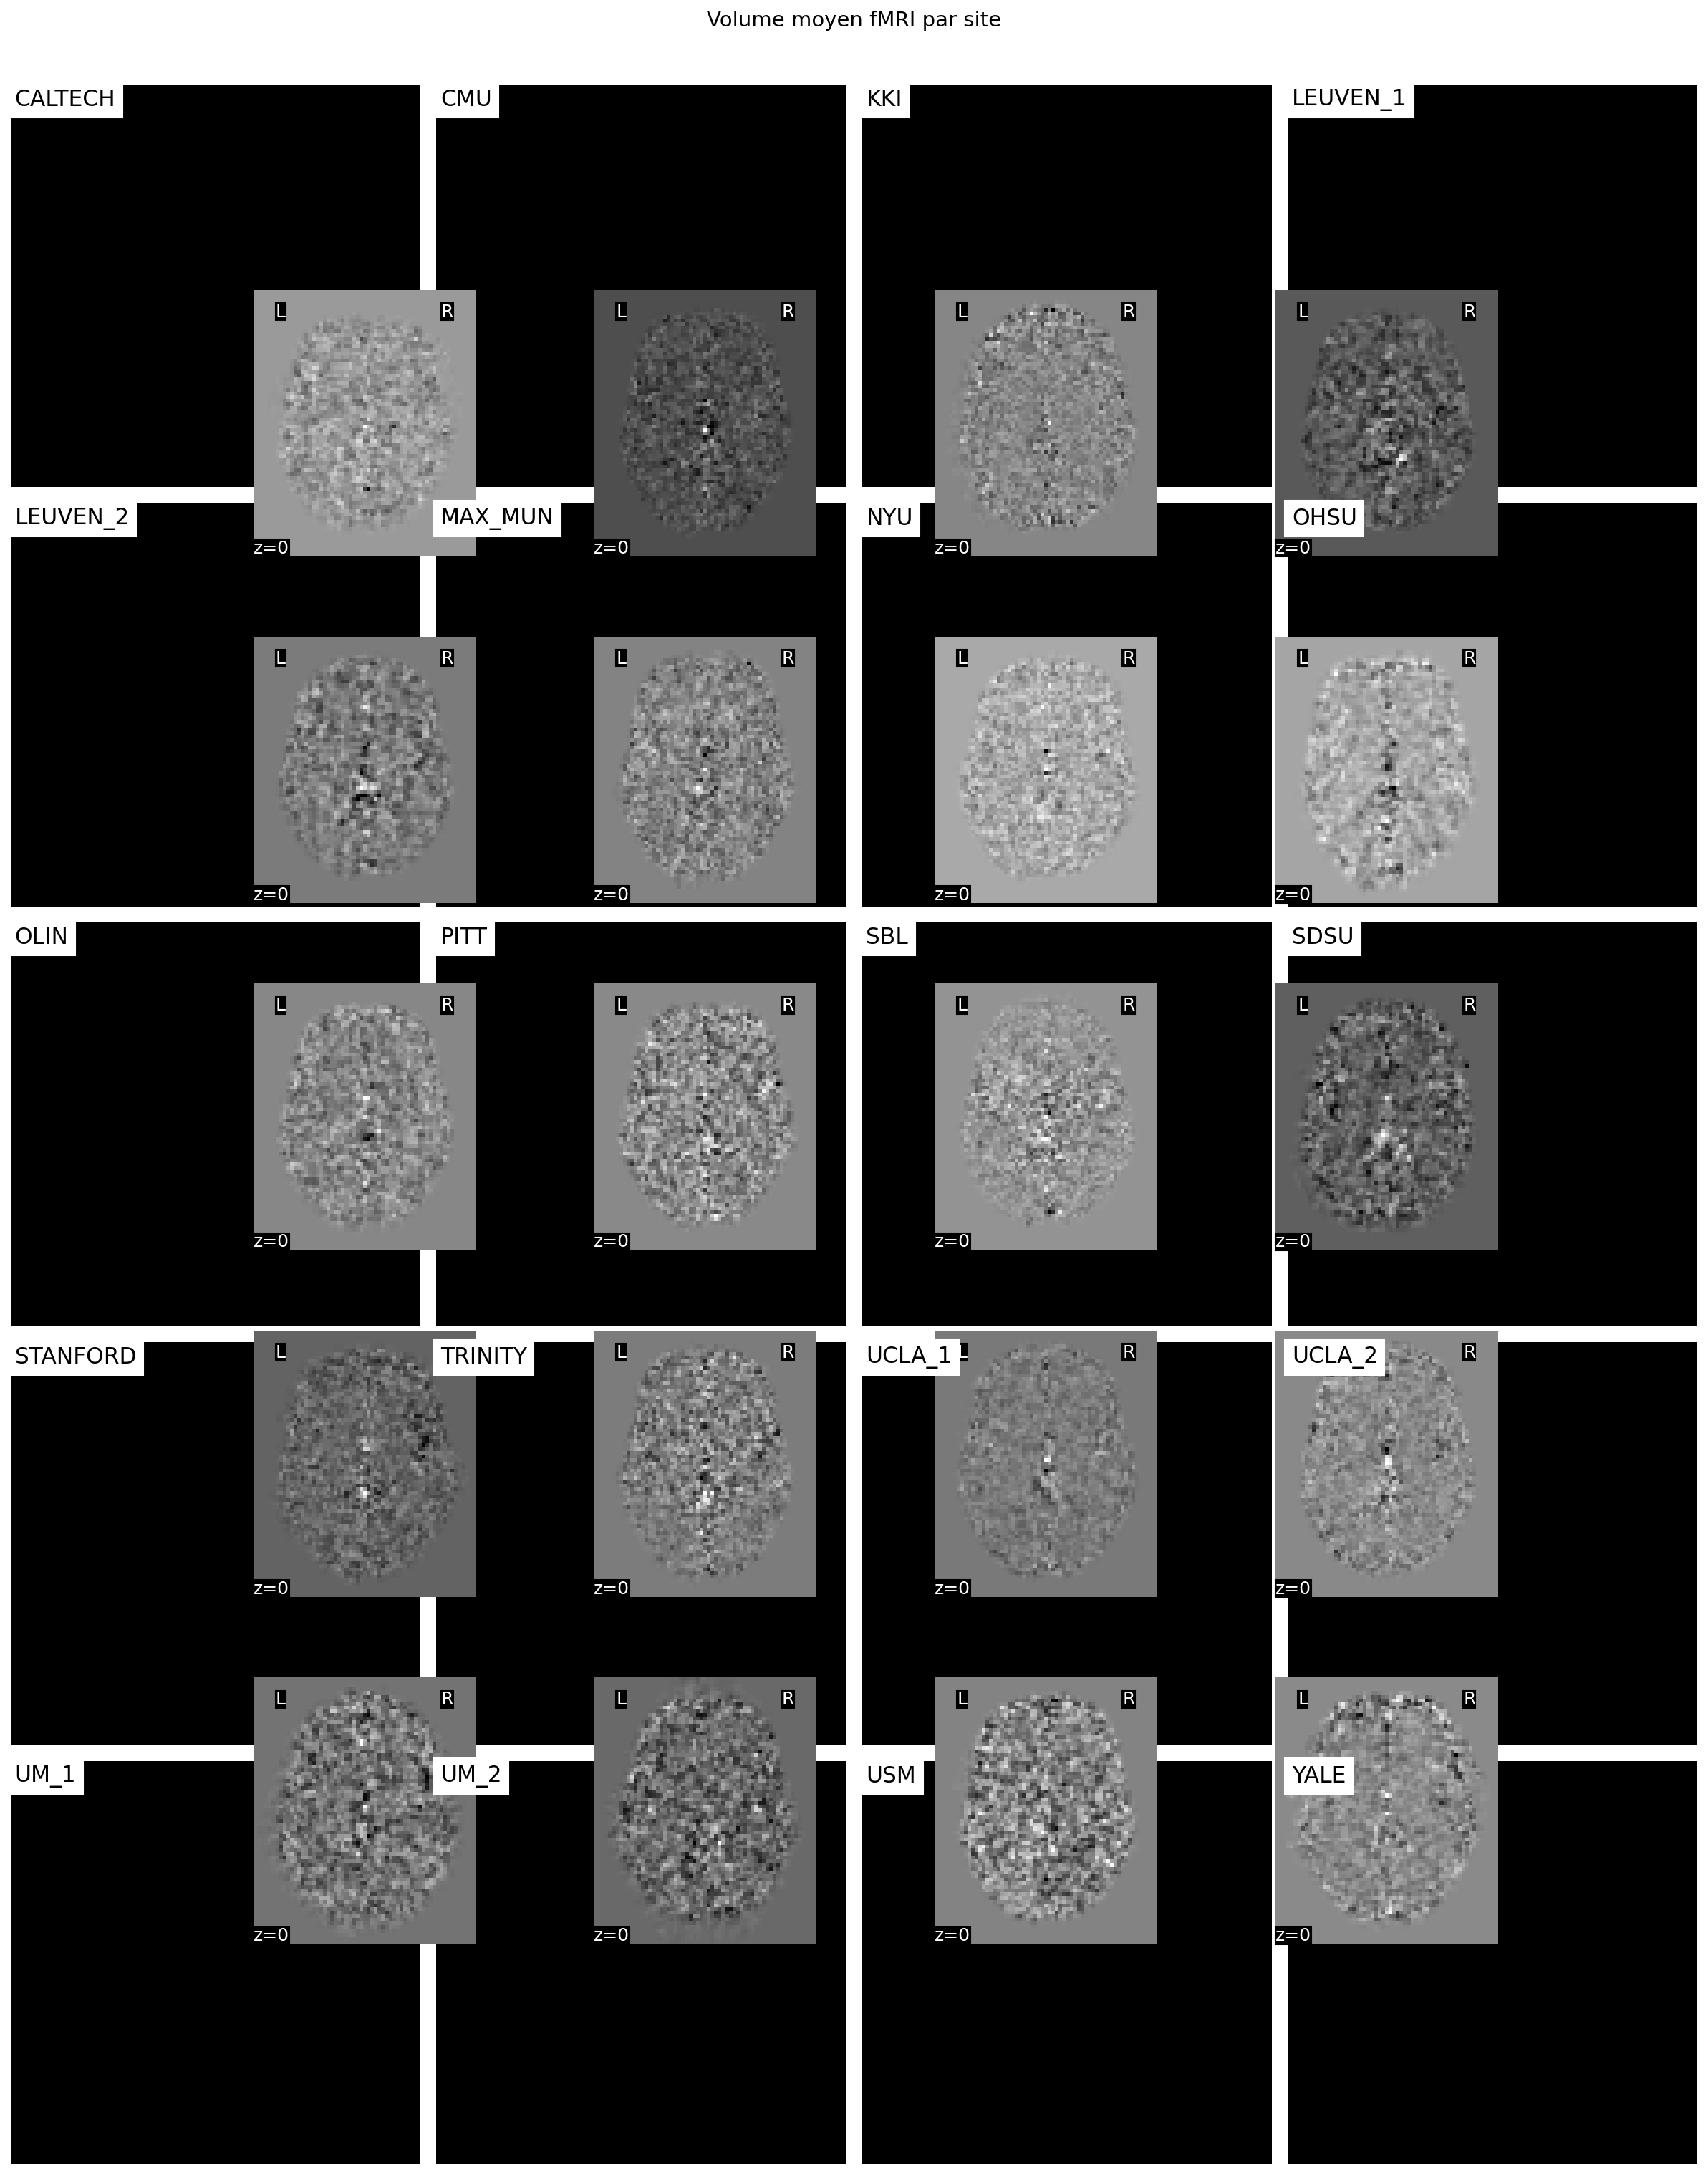

Figure sauvegardée : volume_moyen_par_site.png


In [35]:
# Crée une grille de subplots (un panneau par site)
sites_ok = sorted(site_mean_maps.keys())
n_sites  = len(sites_ok)
ncols    = 4
nrows    = int(np.ceil(n_sites / ncols))


fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
plt.subplots_adjust(hspace=0.3, wspace=0.1)

#fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
#fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
#fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()


# plot_epi = fonction nilearn pour afficher des images fMRI (contraste EPI/T2*)
# display_mode="z" = coupe axiale
# cut_coords=[0] = coupe au niveau z=0 (milieu du cerveau)
for i, site in enumerate(sites_ok):
    plotting.plot_epi(
        site_mean_maps[site],
        axes=axes[i],
        title=site,
        display_mode="z",
        cut_coords=[0],
        colorbar=False,
        draw_cross=False
    )

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Volume moyen fMRI par site", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../output/volume_moyen_par_site.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : volume_moyen_par_site.png")

/tmp/ipykernel_492/2054925537.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


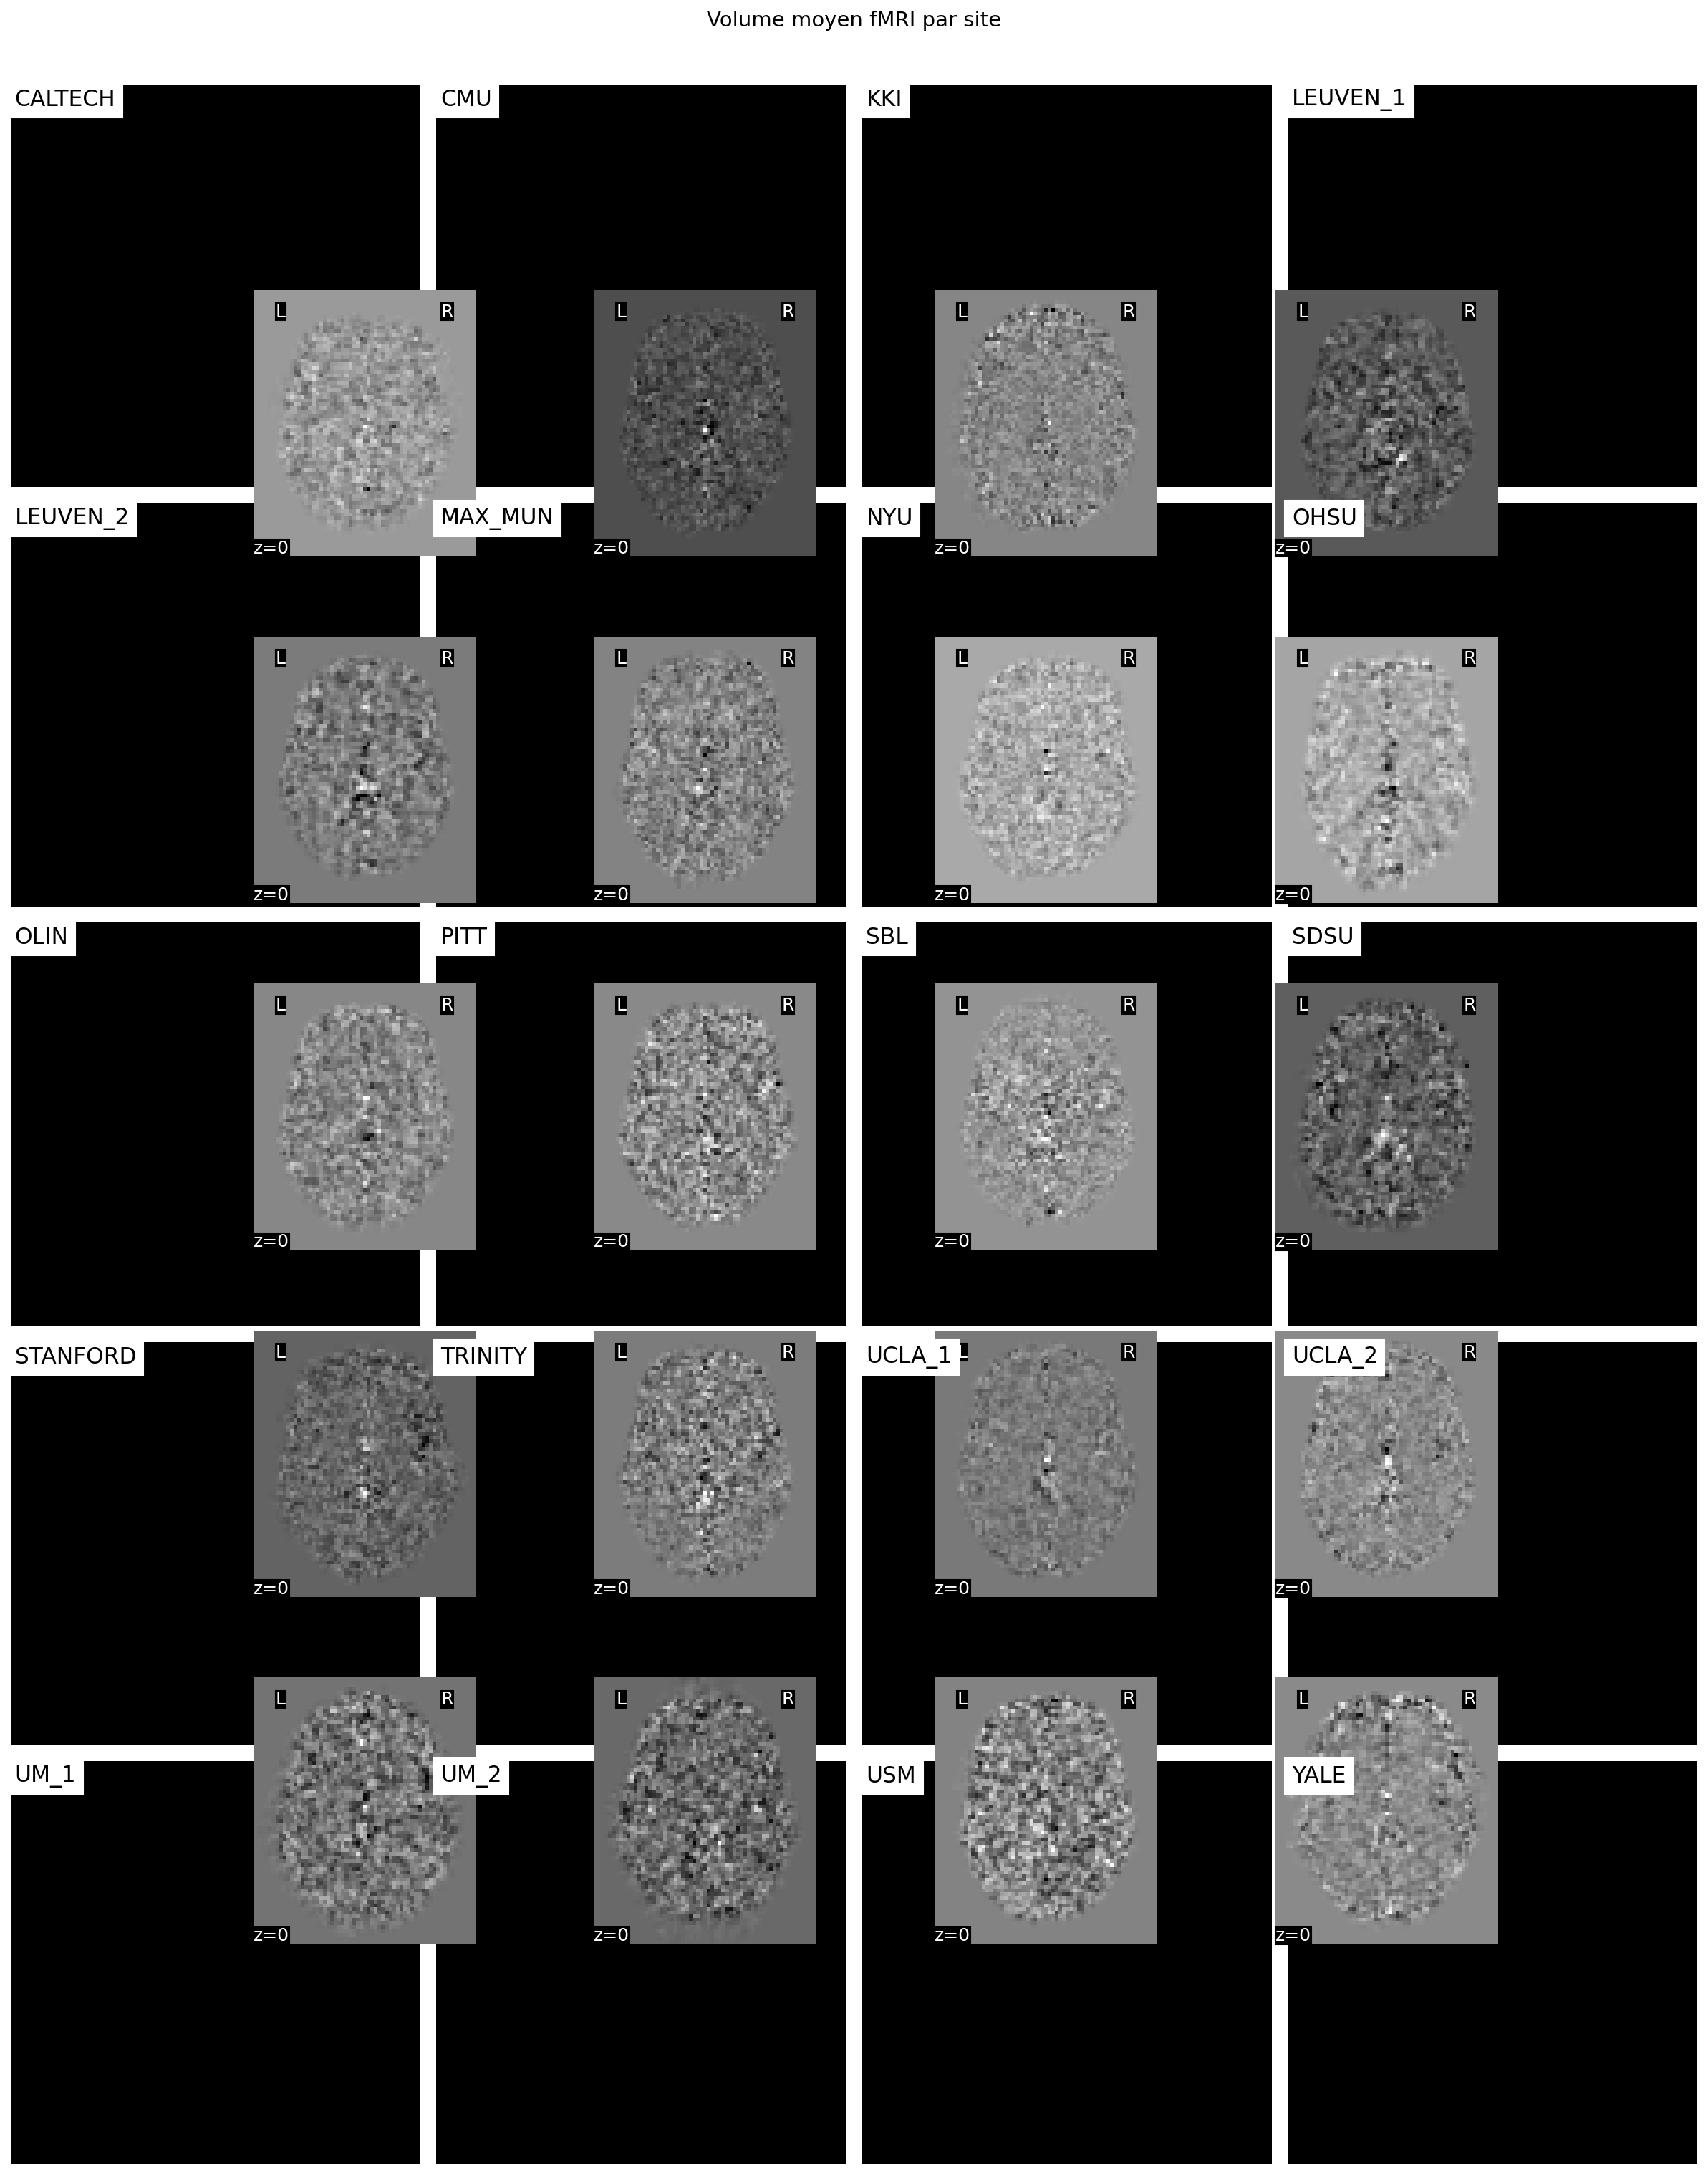

Figure sauvegardée : volume_moyen_par_site.png


In [36]:
# Crée une grille de subplots (un panneau par site)
sites_ok = sorted(site_mean_maps.keys())
n_sites  = len(sites_ok)
ncols    = 4
nrows    = int(np.ceil(n_sites / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
plt.subplots_adjust(hspace=0.3, wspace=0.1)
axes = axes.flatten()

# plot_epi = fonction nilearn pour afficher des images fMRI (contraste EPI/T2*)
# display_mode="z" = coupe axiale
# cut_coords=[0] = coupe au niveau z=0 (milieu du cerveau)
for i, site in enumerate(sites_ok):
    plotting.plot_epi(
        site_mean_maps[site],
        axes=axes[i],
        title=site,
        display_mode="z",
        cut_coords=[0],
        colorbar=False,
        draw_cross=False
    )

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Volume moyen fMRI par site", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../output/volume_moyen_par_site.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : volume_moyen_par_site.png")

### Interprétation : Volume moyen par site :

Les volumes moyens révèlent des différences inter-sites visibles à l'œil nu :
- **Intensité** : CMU est plus sombre, NYU plus clairs → différences de paramètres d'acquisition
- **Résolution** : MAX_MUN a une texture plus grossière  → résolution spatiale plus faible


## 5. Visualisation des cartes d'écart-type temporel (tSD) par site


/tmp/ipykernel_492/2461418828.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


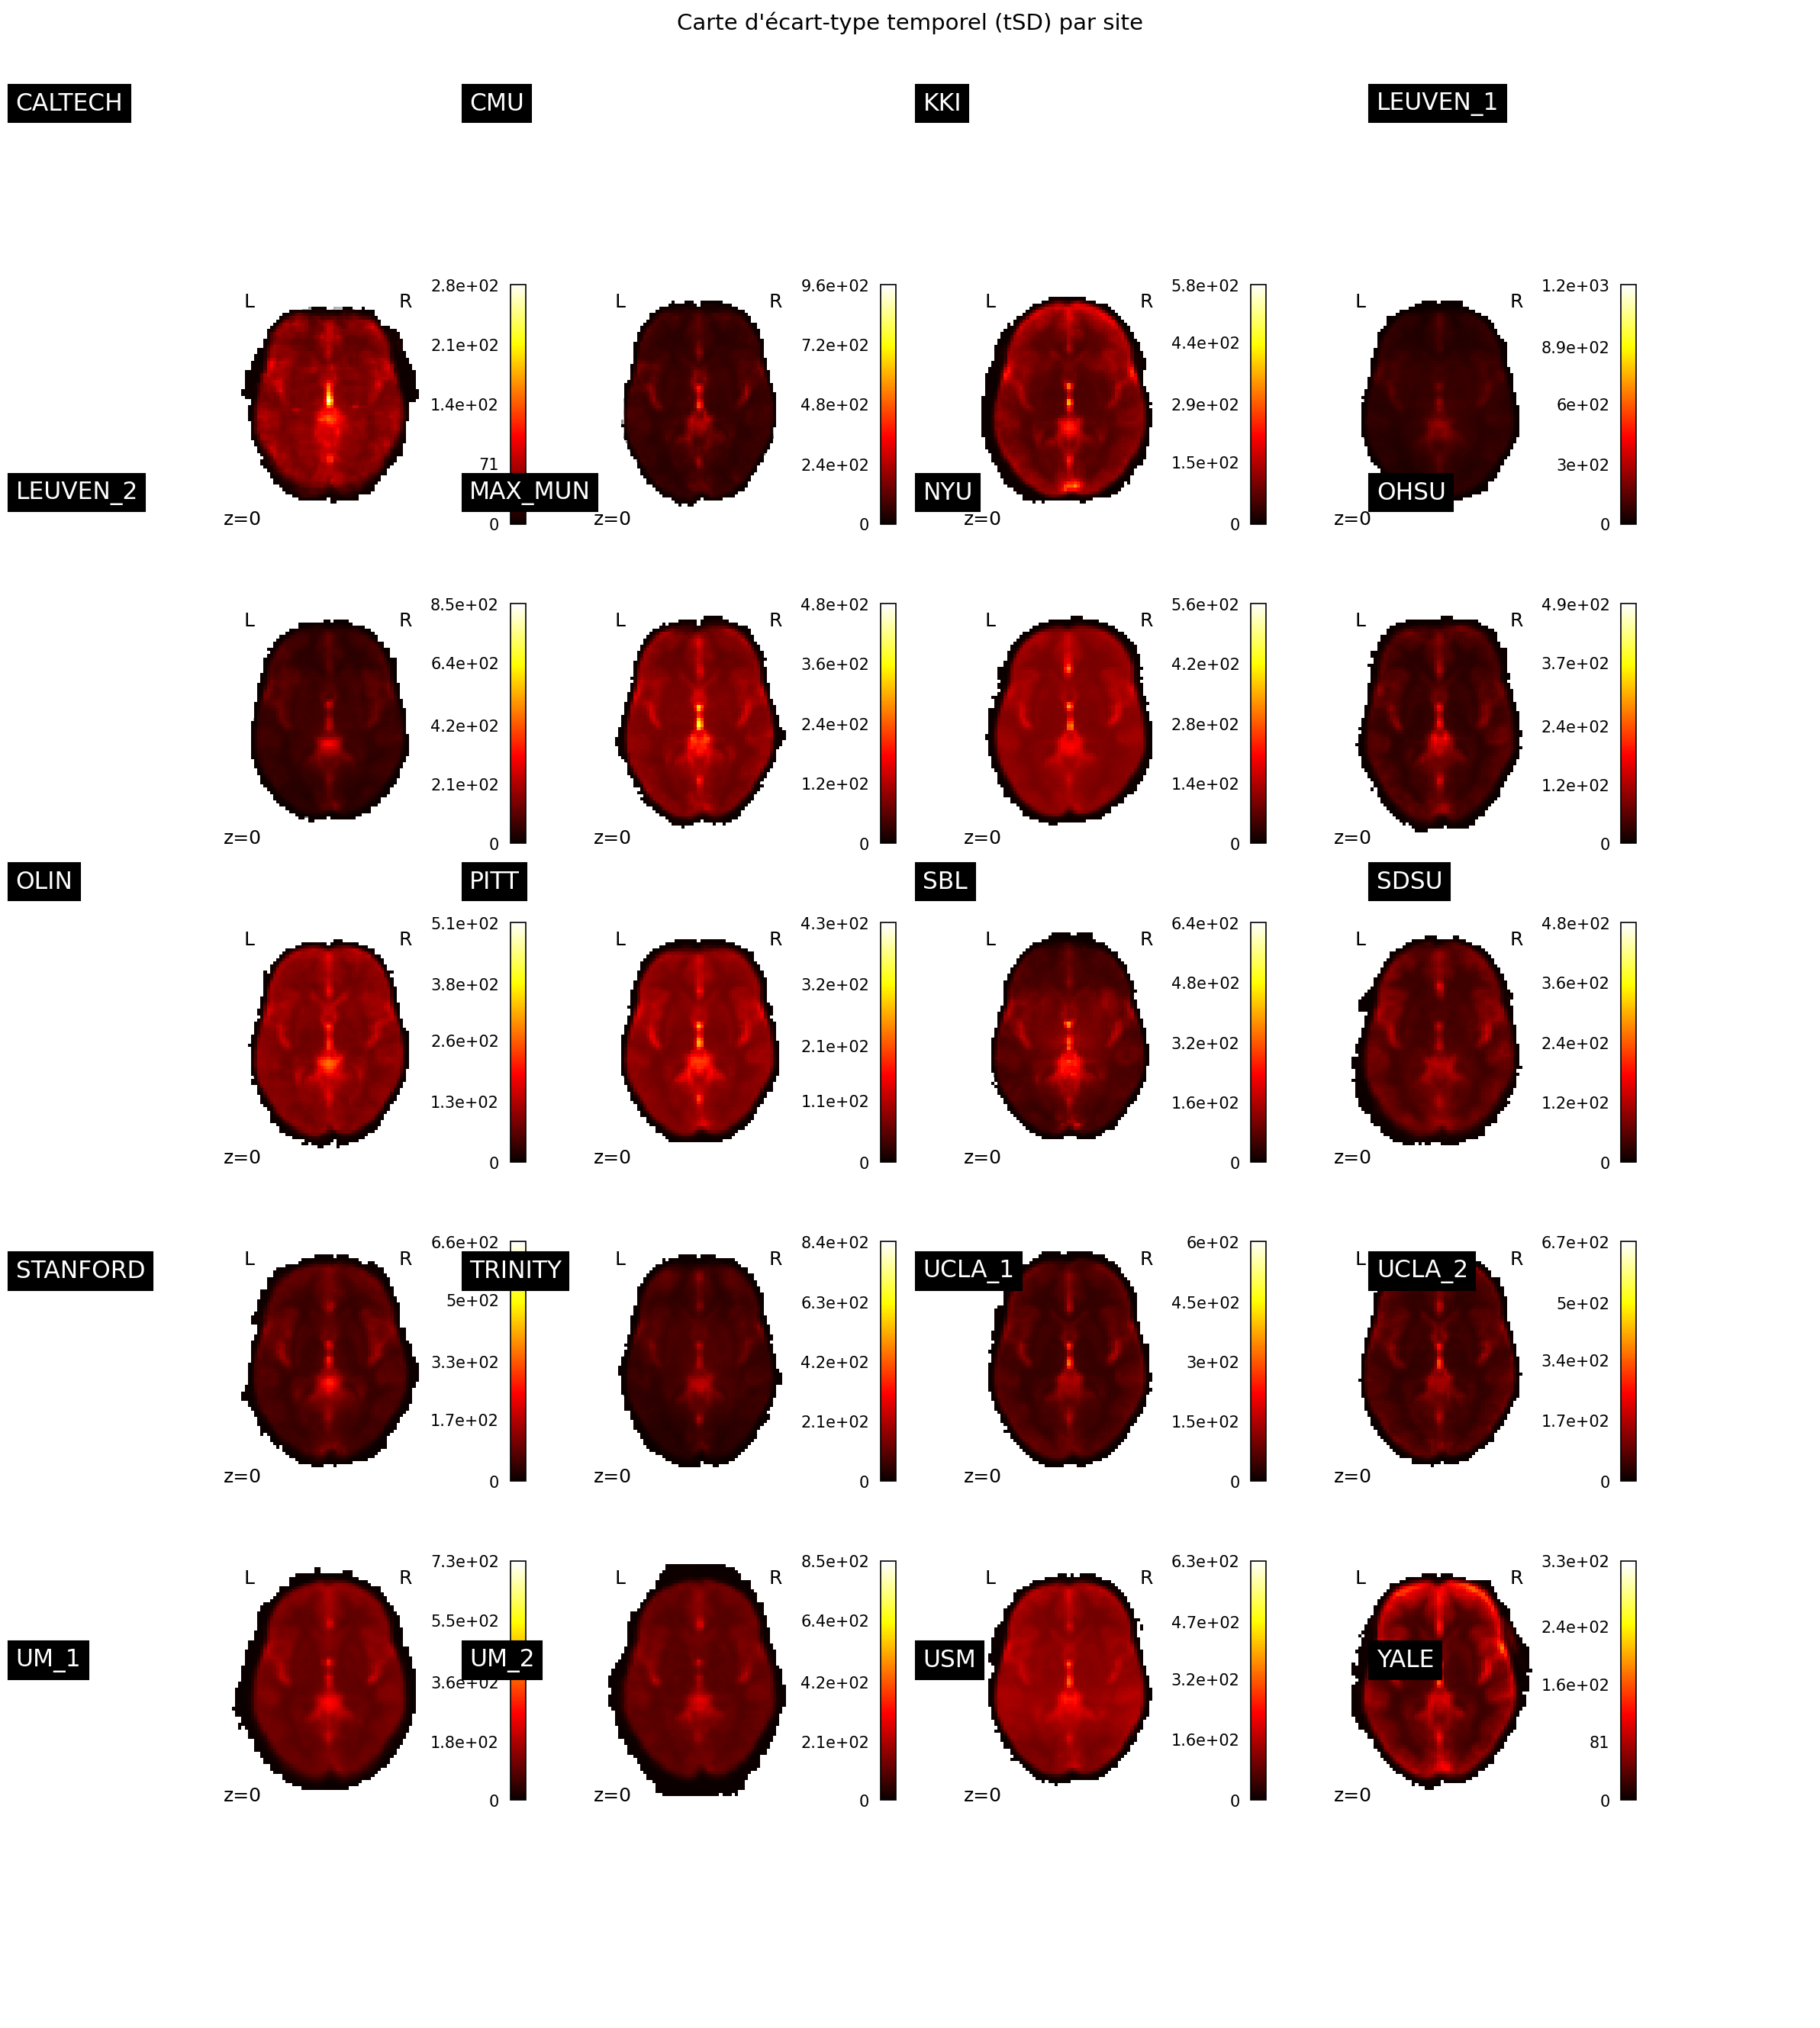

Figure sauvegardée : tSD_par_site.png


In [37]:
# Crée la grille pour les cartes tSD
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, site in enumerate(sites_ok):
    plotting.plot_stat_map(
        site_tsd_maps[site],
        axes=axes[i],
        title=site,
        display_mode="z",
        cut_coords=[0],
        colorbar=True,
        draw_cross=False,
        cmap="hot"
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Carte d'écart-type temporel (tSD) par site", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../output/tSD_par_site.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : tSD_par_site.png")

### Interpretation : carte tSD (carte d'écart-type temporel)

Pour chaque voxel du cerveau, on calcule combien il varie dans le temps

Rouge foncé = voxel qui varie peu → stable
Jaune/blanc = voxel qui varie beaucoup → instable

Ce qu'on voit normalement :
Les zones jaunes devraient être concentrées au centre du cerveau : dans les ventricules et les grandes veines, car ces zones ont naturellement beaucoup de signal BOLD.

Ce qu'on observe dans les figures :

- PITT, NYU : points chauds au centre → normal
- OHSU : variabilité plus diffuse sur tout le cerveau → signe d'artefacts 
- CALTECH : échelle très différente (2.8e+0.2 vs 1.2e+03 pour LEUVEN_1) → unités différentes entre scanners 

In [38]:
print(sites_ok)
print(len(sites_ok))

['CALTECH', 'CMU', 'KKI', 'LEUVEN_1', 'LEUVEN_2', 'MAX_MUN', 'NYU', 'OHSU', 'OLIN', 'PITT', 'SBL', 'SDSU', 'STANFORD', 'TRINITY', 'UCLA_1', 'UCLA_2', 'UM_1', 'UM_2', 'USM', 'YALE']
20


## 6. Focus sur les sites problématiques vs performants

On compare côte à côte les sites qui généralisaient mal en LOSO (OHSU : 0.442, MAX_MUN : 0.499) avec un site performant (LEUVEN_1 : 0.750), pour voir si les différences visuelles correspondent aux différences de performance.

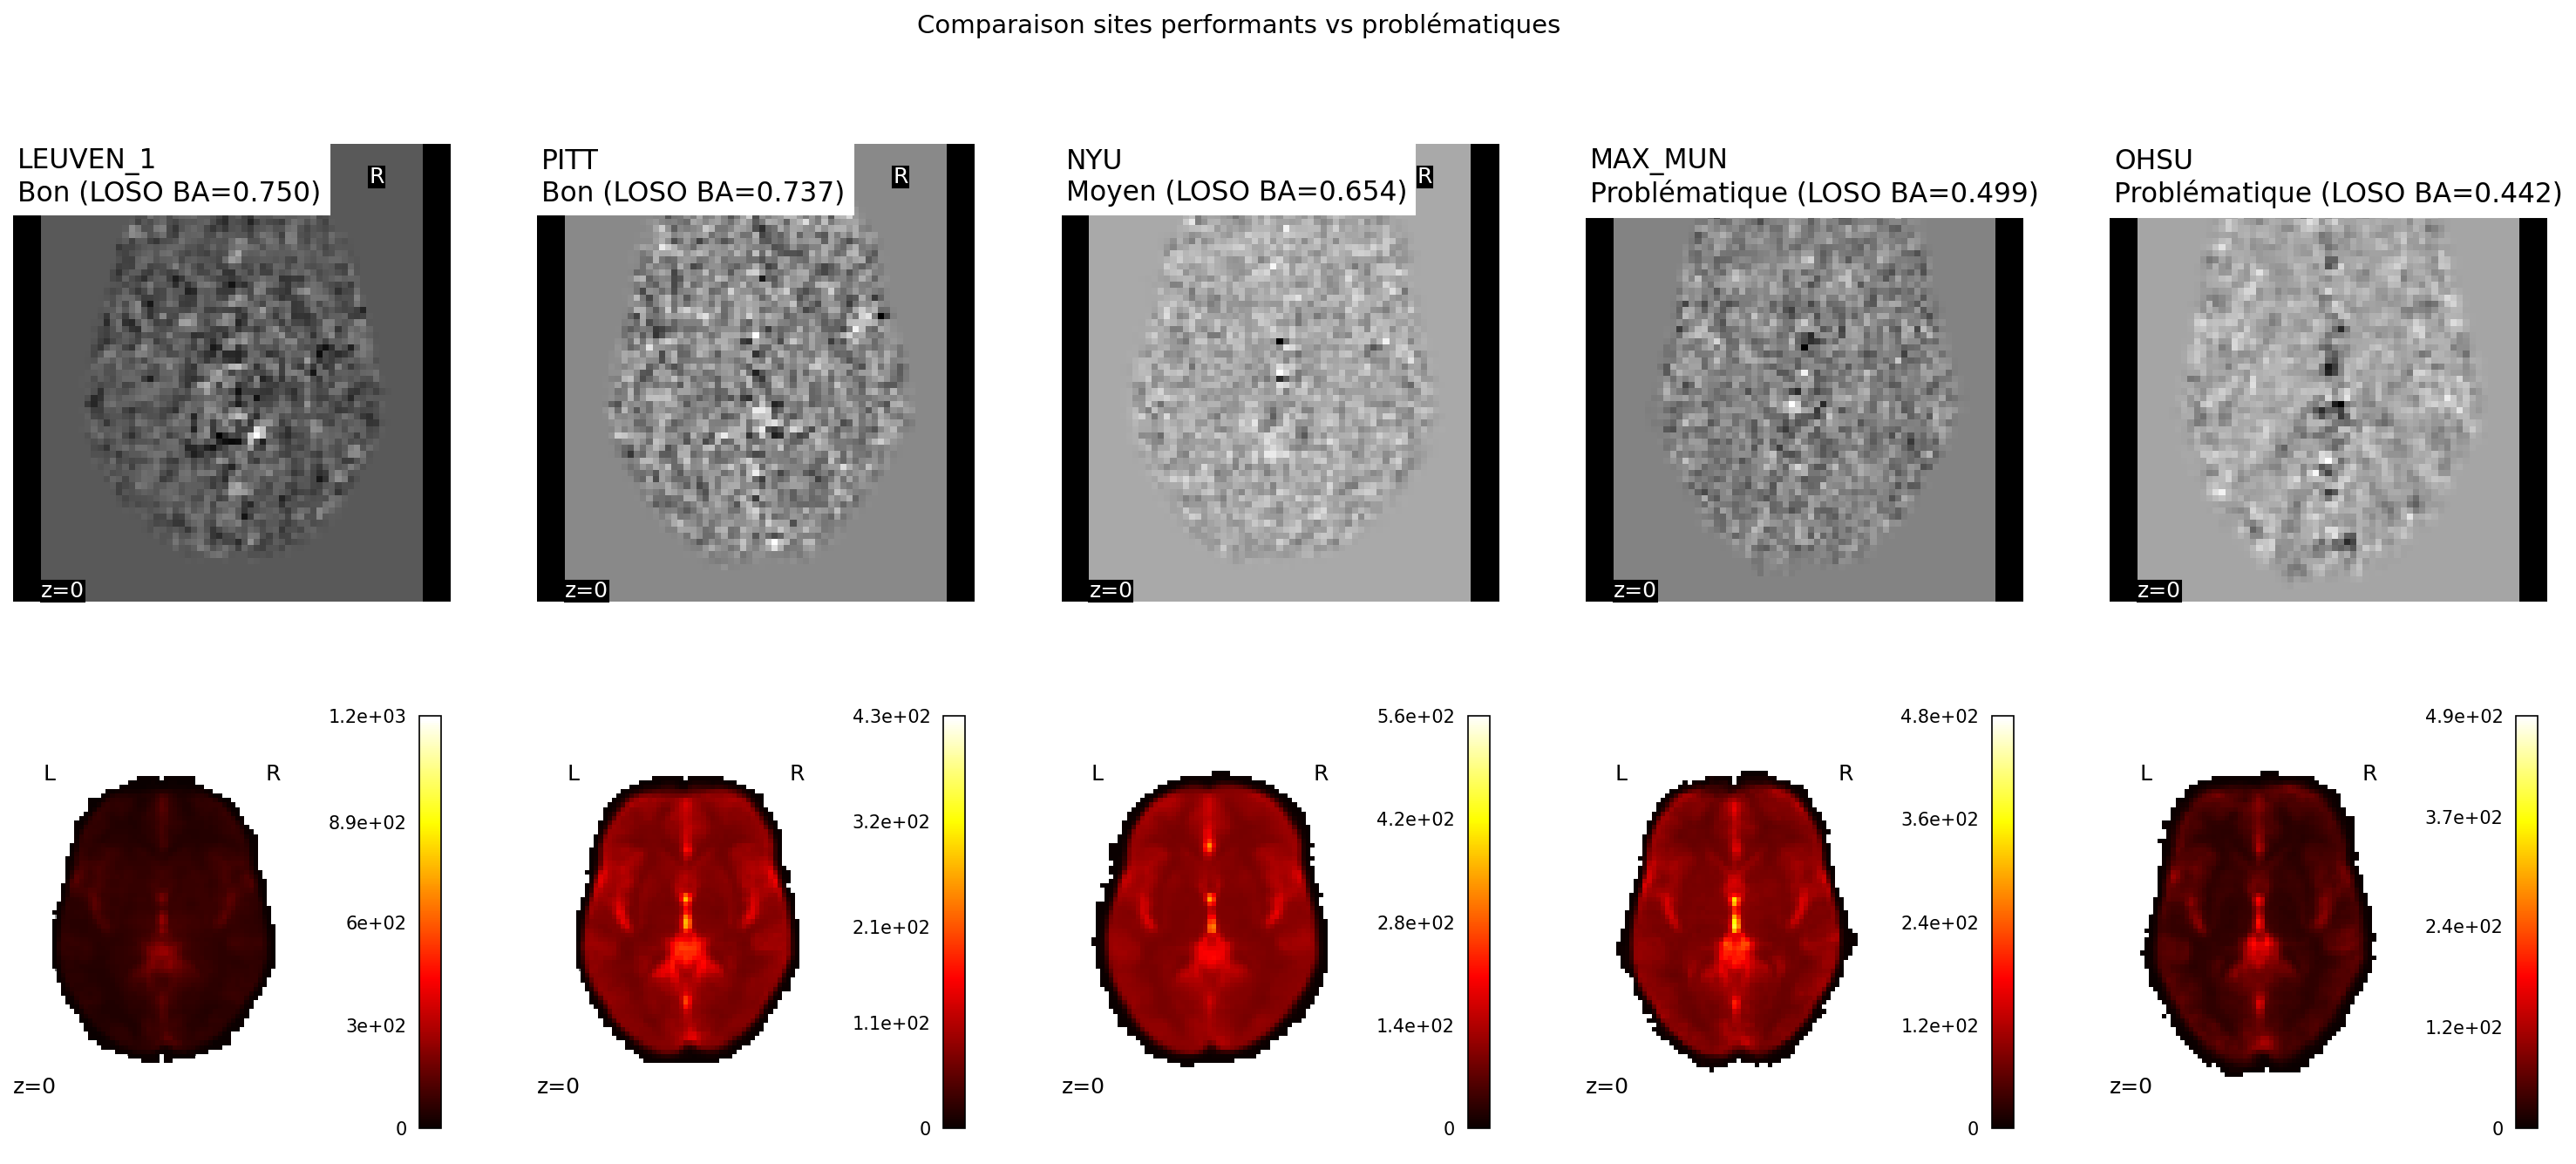

Figure sauvegardée : comparaison_sites_focus.png


In [43]:
# Sites sélectionnés pour la comparaison
# Basé sur les résultats LOSO de la tâche 1
sites_focus = {
    "LEUVEN_1":  "Bon (LOSO BA=0.750)",
    "PITT":      "Bon (LOSO BA=0.737)",
    "NYU":       "Moyen (LOSO BA=0.654)",
    "MAX_MUN":   "Problématique (LOSO BA=0.499)",
    "OHSU":      "Problématique (LOSO BA=0.442)",
}

#fig, axes = plt.subplots(2, len(sites_focus), figsize=(len(sites_focus) * 4, 8))
fig, axes = plt.subplots(2, len(sites_focus), figsize=(len(sites_focus) * 5, 10))

for col, (site, label) in enumerate(sites_focus.items()):
    if site not in site_mean_maps:
        print(f"Attention : Site {site} non disponible")
        continue

    # Ligne 1 : volume moyen
    plotting.plot_epi(
        site_mean_maps[site],
        axes=axes[0, col],
        title=f"{site}\n{label}",
        display_mode="z",
        cut_coords=[0],
        colorbar=False,
        draw_cross=False
    )

    # Ligne 2 : carte tSD
    plotting.plot_stat_map(
        site_tsd_maps[site],
        axes=axes[1, col],
        display_mode="z",
        cut_coords=[0],
        colorbar=True,
        draw_cross=False,
        cmap="hot"
    )

axes[0, 0].set_ylabel("Volume moyen", fontsize=11)
axes[1, 0].set_ylabel("Carte tSD", fontsize=11)

fig.suptitle("Comparaison sites performants vs problématiques", fontsize=14)
#plt.tight_layout()
plt.savefig("../output/comparaison_sites_focus.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : comparaison_sites_focus.png")

### Interprétation : Comparaison sites performants vs problématiques :

**Ligne 1 : Volume moyen :**
- **Intensité** : LEUVEN_1 est plus sombre que PITT et NYU → différences de paramètres d'acquisition entre scanners
- **Résolution** : MAX_MUN a une texture plus grossière  → résolution spatiale plus faible

**Ligne 2 : Carte tSD :**
- PITT, NYU : points chauds au centre → normal
- OHSU : variabilité plus diffuse sur tout le cerveau → signe d'artefacts 
- CALTECH : échelle très différente (2.8e+0.2 vs 1.2e+03 pour LEUVEN_1) → unités différentes entre scanners
  
**Lien avec la tâche 1 :**
Ces différences visuelles expliquent pourquoi certains sites généralisent mal en LOSO :
- OHSU (BA=0.442) : variabilité diffuse sur tout le cerveau → artefacts résiduels que le modèle ne reconnaît pas
- MAX_MUN (BA=0.499) : résolution plus faible → données structurellement différentes des autres sites

À l'inverse, PITT (BA=0.737) et LEUVEN_1 (BA=0.750) ont des images propres → le modèle généralise bien sur ces sites.

La tâche 2 avait montré que ce n'est pas l'âge qui explique ces différences. La tâche 3 confirme que c'est bien les **caractéristiques d'acquisition des scanners** qui sont en cause.

/tmp/ipykernel_492/821329938.py:3: UserWarning: The given float value must not exceed 1.9312842880481185e-07. But, you have given threshold=1e-06.
  view = plotting.view_img(site_mean_maps[site_choisi],
/tmp/ipykernel_492/821329938.py:3: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=1e-06.
  view = plotting.view_img(site_mean_maps[site_choisi],
/home/mariefrc/miniconda3/envs/env_abide/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_492/821329938.py:3: UserWarning: Could not determine cut coords: All voxels were masked by the thresholding. Returning the center of mass instead.
  view = plotting.view_img(site_mean_maps[site_choisi],



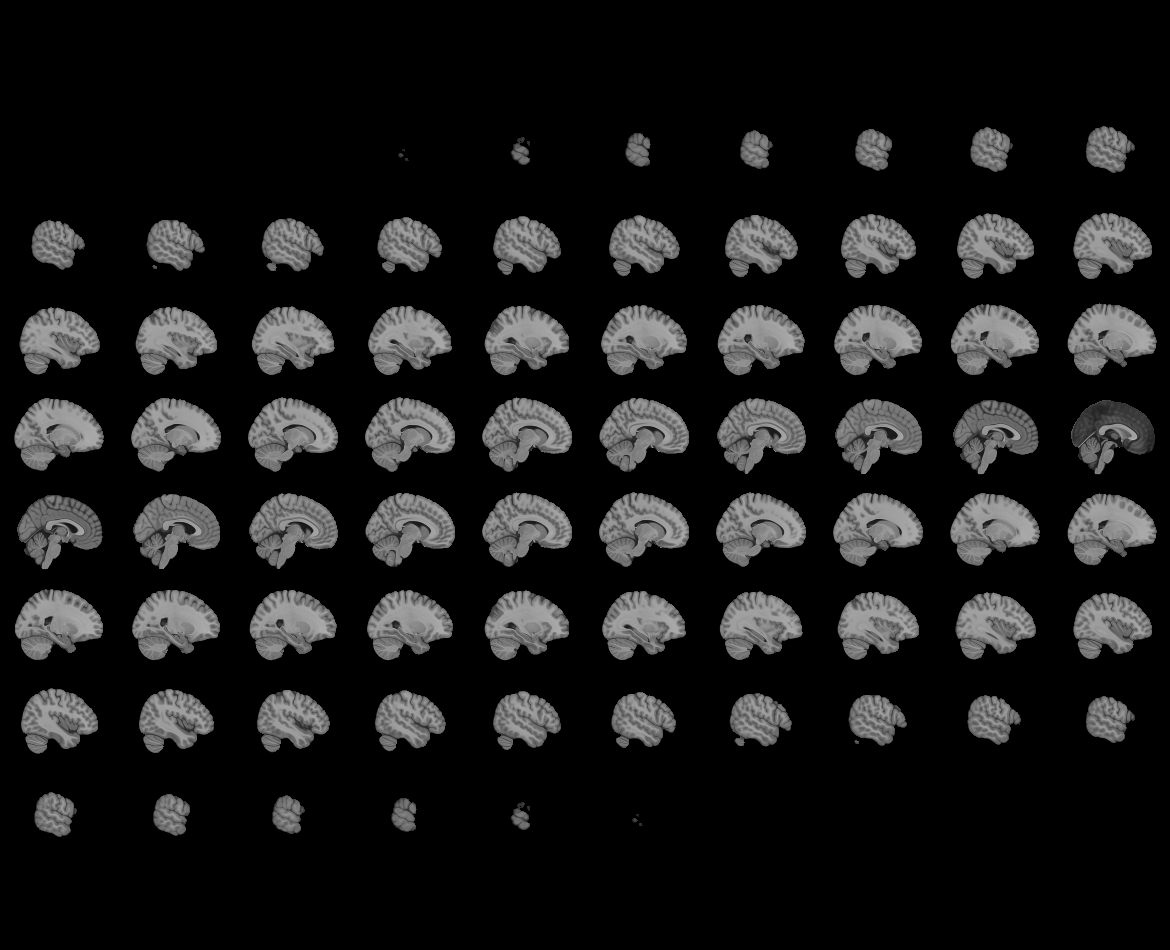
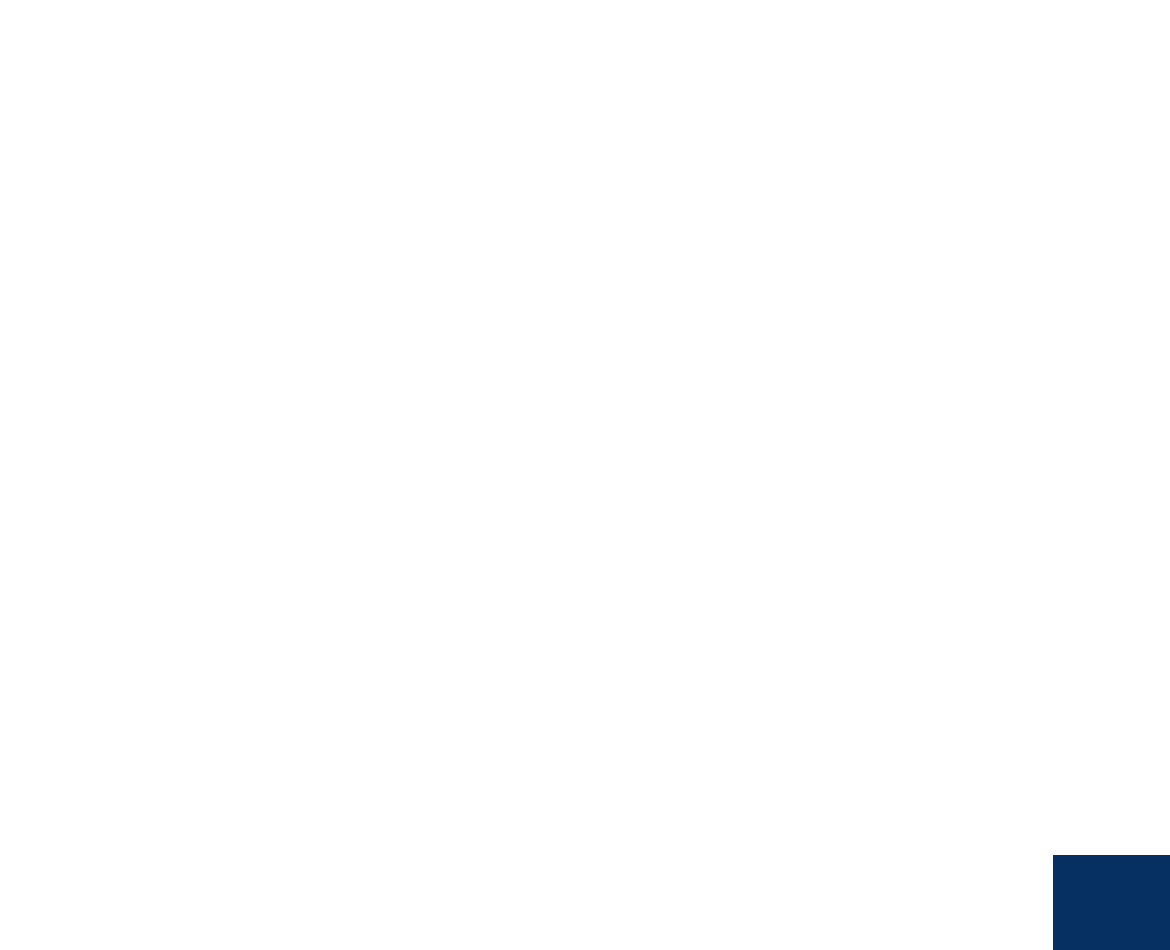

In [47]:
# Visualisation interactive : choisir un site
site_choisi = "NYU"  # changer selon le site voulu
view = plotting.view_img(site_mean_maps[site_choisi], 
                         title=f"Volume moyen : {site_choisi}")
view.save_as_html(f"../output/volume_interactif_{site_choisi}.html")
view

In [45]:
# Vérifie juste un fichier NYU pour comprendre le problème
nyu_files = df_files[df_files["site"] == "NYU"]["filepath"].tolist()
img = nib.load(str(nyu_files[0]))
print("Nom du fichier :", nyu_files[0].name)
print("Dimensions :", img.shape)
print("Valeurs min/max :", img.get_fdata().min().round(2), img.get_fdata().max().round(2))

Nom du fichier : NYU_0050952_func_preproc.nii.gz
Dimensions : (61, 73, 61, 176)
Valeurs min/max : -6098.97 9307.59


In [46]:
# Vérifie juste un fichier NYU pour comprendre le problème
nyu_files = df_files[df_files["site"] == "NYU"]["filepath"].tolist()
img = nib.load(str(nyu_files[0]))
print("Nom du fichier :", nyu_files[0].name)
print("Dimensions :", img.shape)
print("Valeurs min/max :", img.get_fdata().min().round(2), img.get_fdata().max().round(2))


Nom du fichier : NYU_0050952_func_preproc.nii.gz
Dimensions : (61, 73, 61, 176)
Valeurs min/max : -6098.97 9307.59


Note sur la visualisation interactive :
Les fichiers chargés sont bien des images fMRI 4D 
(ex: NYU: dimensions 61×73×61×176, valeurs BOLD normales).

L'apparence "T1-like" de la visualisation interactive est due à la normalisation automatique de `nilearn.plotting.view_img` qui lisse les contrastes pour l'affichage interactif.

Les visualisations statiques (tSD_par_site) sont plus représentatives du vrai contraste fMRI.